In [1]:
import numpy as np
from AttitudeAgentTestAviary import AttitudeTestAviary

In [2]:
env = AttitudeTestAviary()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [3]:
from stable_baselines3 import PPO
rlagent = PPO.load("attitude_sb3_logs/PPO_Attitude2_3_1500k")

In [4]:
from DSLPIDAttitudeControl import DSLPIDAttitudeControl

pidagent = DSLPIDAttitudeControl()

In [5]:
def obs_to_rlagent_obs(obs, env):
    target_rpys = env.target_rpys
    filtered_obs = np.hstack([obs[7:10]/np.pi, obs[13:16]/np.linalg.norm(obs[13:16]), target_rpys]).reshape(9,)
    return filtered_obs

def obs_to_pidagent_obs(obs, env):
    target_rpys = env.target_rpys
    return np.hstack([obs, env.TIMESTEP, obs[:3], target_rpys]).reshape(27,)

In [6]:
# # RL agent
# targets1 = []
# actuals1 = []

# done = False

# obs = env.reset()
# obs = obs_to_rlagent_obs(obs, env)
# while not done:
#     action, _states = rlagent.predict(obs)

#     obs, reward, done, info = env.step(action)
#     obs = obs_to_rlagent_obs(obs, env)

#     actuals1.append(obs[:3]*np.pi)
#     targets1.append(obs[-3:])

In [7]:
# PID agent
targets2 = []
actuals2 = []

done = False

obs = env.reset()
obs = obs_to_pidagent_obs(obs, env)
while not done:
    action, _, _ = pidagent.predict(obs)

    obs, reward, done, info = env.step(action)
    obs = obs_to_pidagent_obs(obs, env)

    actuals2.append(obs[:3])
    targets2.append(obs[-3:])

In [8]:
# target1_r = [x[0] for x in targets1]
# target1_p = [x[1] for x in targets1]
# target1_y = [x[2] for x in targets1]

# actual1_r = [x[0] for x in actuals1]
# actual1_p = [x[1] for x in actuals1]
# actual1_y = [x[2] for x in actuals1]

In [9]:
target2_r = [x[0] for x in targets2]
target2_p = [x[1] for x in targets2]
target2_y = [x[2] for x in targets2]

actual2_r = [x[0] for x in actuals2]
actual2_p = [x[1] for x in actuals2]
actual2_y = [x[2] for x in actuals2]

In [10]:
import matplotlib.pyplot as plt

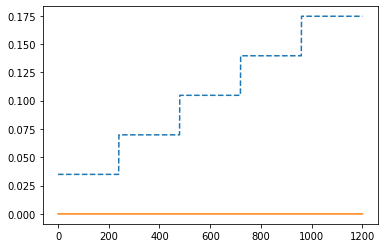

In [11]:
plt.figure()
plt.plot(range(len(target2_r)), target2_r, "--")
plt.plot(range(len(actual2_r)), actual2_r)
plt.show()

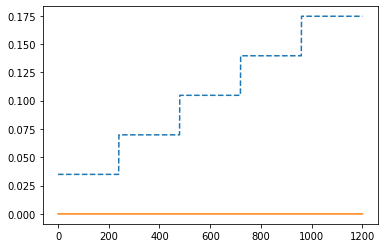

In [12]:
plt.figure()
plt.plot(range(len(target2_p)), target2_p, "--")
plt.plot(range(len(actual2_p)), actual2_p)
plt.show()

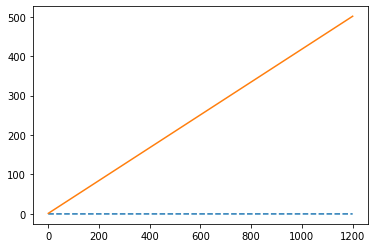

In [13]:
plt.figure()
plt.plot(range(len(target2_y)), target2_y, "--")
plt.plot(range(len(actual2_y)), actual2_y)
plt.show()